In [32]:
import pandas as pd
df = pd.read_csv('student_performance_data.csv')

# First look at the data

In [33]:
df.head()

,student_id,gender,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,internet_access,extra_classes,parent_education,sleep_hours,overall_score,grade
0,100000,Male,4.54,69.98,36.47,70.70,53.10,17.96,Yes,No,Master,8.09,52.3480,D
1,100001,Female,5.26,84.80,34.25,27.92,87.17,11.29,No,Yes,Bachelor,4.73,53.9485,D
2,100002,Male,8.69,73.76,72.29,70.92,99.61,76.10,No,Yes,PhD,8.73,82.0375,B
3,100003,Male,4.06,45.00,97.63,31.73,88.85,33.55,No,No,Bachelor,8.22,66.4110,C
4,100004,Male,8.83,51.13,65.19,78.28,54.23,88.99,No,No,Bachelor,8.59,65.6005,C


# Info on the data

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             10000 non-null  int64  
 1   gender                 10000 non-null  str    
 2   study_hours_per_day    10000 non-null  float64
 3   attendance_percentage  10000 non-null  float64
 4   assignment_score       10000 non-null  float64
 5   midterm_score          10000 non-null  float64
 6   final_exam_score       10000 non-null  float64
 7   participation_score    10000 non-null  float64
 8   internet_access        10000 non-null  str    
 9   extra_classes          10000 non-null  str    
 10  parent_education       10000 non-null  str    
 11  sleep_hours            10000 non-null  float64
 12  overall_score          10000 non-null  float64
 13  grade                  10000 non-null  str    
dtypes: float64(8), int64(1), str(5)
memory usage: 1.1 MB


# Summary Stats

In [35]:
df.describe()

,student_id,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,sleep_hours,overall_score
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,104999.50000,5.467825,70.493817,64.717809,62.322568,64.979987,55.103202,6.505165,63.826901
std,2886.89568,2.594134,17.295607,20.052779,21.710555,20.216141,25.955949,1.458246,10.230977
min,100000.00000,1.000000,40.000000,30.000000,25.000000,30.010000,10.000000,4.000000,33.263500
25%,102499.75000,3.220000,55.640000,47.320000,43.515000,47.400000,32.955000,5.220000,56.528125
50%,104999.50000,5.420000,70.780000,64.770000,62.050000,65.210000,55.055000,6.520000,63.780750
75%,107499.25000,7.740000,85.200000,81.760000,81.227500,82.500000,77.760000,7.792500,71.163125
max,109999.00000,10.000000,100.000000,99.990000,100.000000,100.000000,99.990000,9.000000,96.879500


# Shape of data

In [36]:
print("Rows, Columns:", df.shape)

Rows, Columns: (10000, 14)


# Are there any duplicates? After reviewing the code: no

In [ ]:
print(df.duplicated().sum())

Duplicate rows: 0


# Check current data types. They are properly assigned

In [37]:

print(df.dtypes)

student_id                 int64
gender                       str
study_hours_per_day      float64
attendance_percentage    float64
assignment_score         float64
midterm_score            float64
final_exam_score         float64
participation_score      float64
internet_access              str
extra_classes                str
parent_education             str
sleep_hours              float64
overall_score            float64
grade                        str
dtype: object


# Check for missing values. No missing values

In [38]:
print(df.isnull().sum())

student_id               0
gender                   0
study_hours_per_day      0
attendance_percentage    0
assignment_score         0
midterm_score            0
final_exam_score         0
participation_score      0
internet_access          0
extra_classes            0
parent_education         0
sleep_hours              0
overall_score            0
grade                    0
dtype: int64


# Stripping extra spaces off string columns

In [39]:
category_columns = ['gender', 'internet_access','extra_classes','parent_education','grade']

for col in category_columns:
    df[col] = df[col].astype(str).str.strip()

# Usually Yes/No are not standard values in a database. Updating the mapping for internet access and extra classes to be 1 and 0 vs Yes and No.

In [40]:
df['internet_access'] = df['internet_access'].map({'Yes':1, 'No':0})

In [41]:
df['extra_classes'] = df['extra_classes'].map({'Yes':1, 'No':0})

# Checking the columns after stripping them and reassigning values

In [42]:
df.head()

,student_id,gender,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,internet_access,extra_classes,parent_education,sleep_hours,overall_score,grade
0,100000,Male,4.54,69.98,36.47,70.70,53.10,17.96,1,0,Master,8.09,52.3480,D
1,100001,Female,5.26,84.80,34.25,27.92,87.17,11.29,0,1,Bachelor,4.73,53.9485,D
2,100002,Male,8.69,73.76,72.29,70.92,99.61,76.10,0,1,PhD,8.73,82.0375,B
3,100003,Male,4.06,45.00,97.63,31.73,88.85,33.55,0,0,Bachelor,8.22,66.4110,C
4,100004,Male,8.83,51.13,65.19,78.28,54.23,88.99,0,0,Bachelor,8.59,65.6005,C


# Generating a boxpolot to check the data for outliers. (A few in overall score)

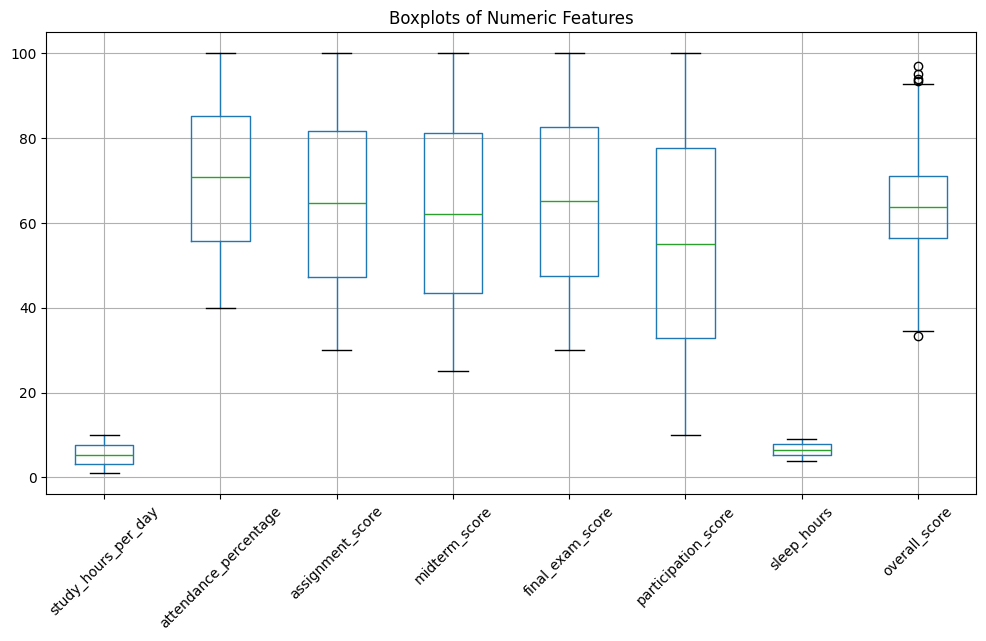

In [15]:
import matplotlib.pyplot as plt

columns_to_plot = ['study_hours_per_day','attendance_percentage', 'assignment_score','midterm_score','final_exam_score', 'participation_score','sleep_hours','overall_score']

df[columns_to_plot].boxplot(figsize=(12,6))

plt.xticks(rotation=45)
plt.title("Boxplots of Numeric Features")
plt.show()


# Adding a correlation plot. There is the highest correlation between overall score and final exam score

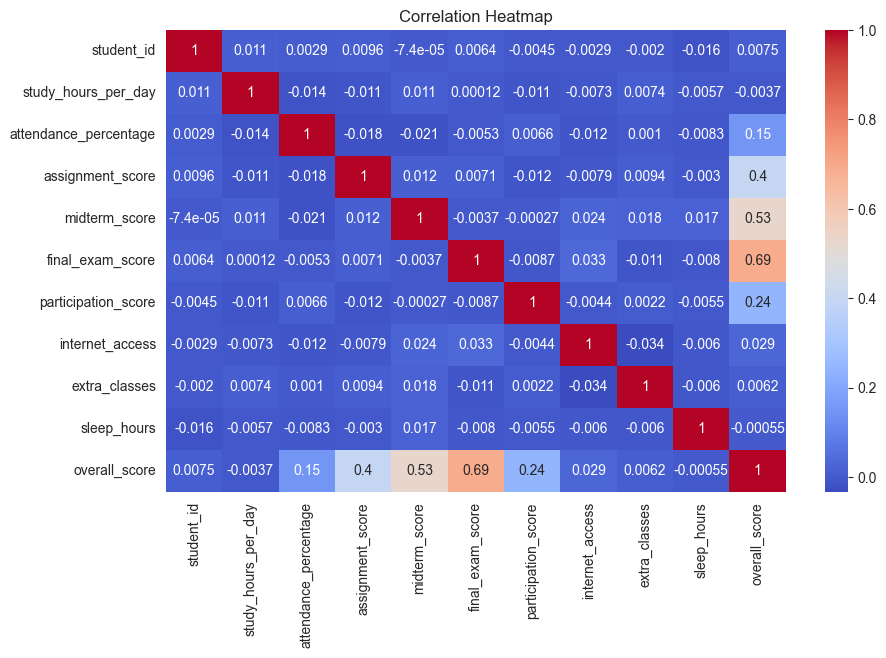

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap( df.corr(numeric_only=True), annot=True,cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

# Adding a histogram to check the distribution of the data. Its a pretty even spread across categories.

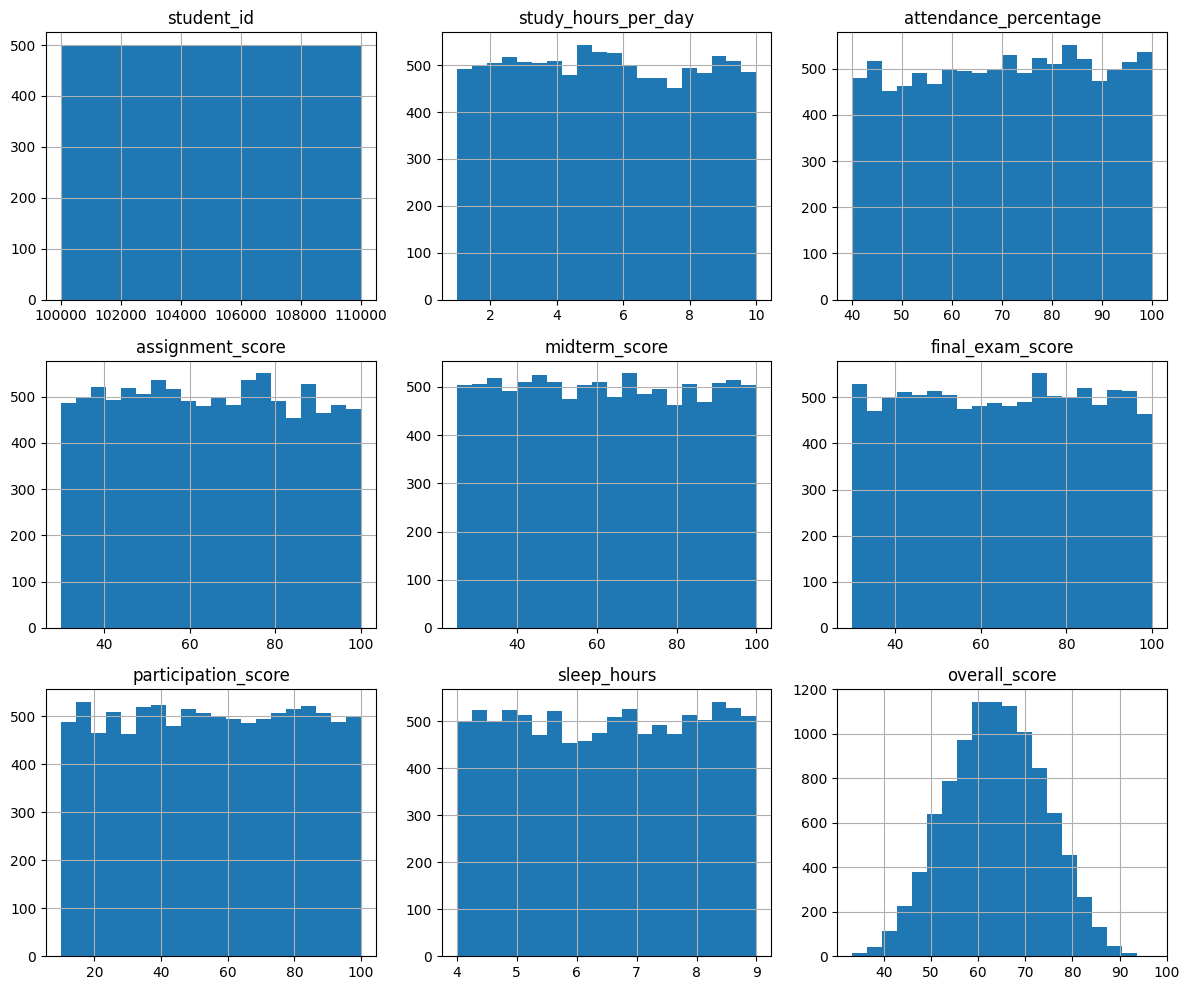

In [17]:
df.hist(figsize=(12,10), bins=20)

plt.tight_layout()
plt.show()

# Below are some summary values to start analyzing the data. I am not seeing much difference between parent education level and score or gender and score or internet access and score.

In [18]:
gender_avg = df.groupby('gender')['overall_score'].mean()

print(gender_avg)

gender
Female    63.830053
Male      63.823766
Name: overall_score, dtype: float64


In [19]:
parent_avg = df.groupby('parent_education')['overall_score'].mean()

print(parent_avg.sort_values(ascending=False))

parent_education
Bachelor       64.008239
Master         63.920976
High School    63.753196
PhD            63.621093
Name: overall_score, dtype: float64


In [ ]:
internet_summary = df.groupby('internet_access')['overall_score'].mean()

print(internet_summary)

internet_access
No     63.525771
Yes    64.120773
Name: overall_score, dtype: float64


In [21]:
top_students = df.sort_values(
    by='overall_score',
    ascending=False
)

print(top_students.head(10))

      student_id  gender  study_hours_per_day  attendance_percentage  \
5745      105745    Male                 6.22                  98.96   
8453      108453    Male                 2.55                  98.61   
7374      107374  Female                 9.21                  91.41   
3598      103598  Female                 5.68                  81.95   
4667      104667  Female                 2.97                  47.49   
12        100012    Male                 5.82                  99.06   
7472      107472  Female                 3.63                  91.97   
7667      107667    Male                 7.83                  92.88   
8563      108563  Female                 6.01                  94.83   
2135      102135    Male                 7.65                  97.13   

      assignment_score  midterm_score  final_exam_score  participation_score  \
5745             96.15          99.64             97.79                86.17   
8453             88.66          98.96          

In [23]:
summary_table = df.groupby('grade').agg({
    'overall_score': ['mean', 'min', 'max'],
    'study_hours_per_day': 'mean',
    'attendance_percentage': 'mean',
    'sleep_hours': 'mean'
})

print(summary_table)

      overall_score                   study_hours_per_day  \
               mean      min      max                mean   
grade                                                       
A         87.579114  85.0175  96.8795            5.293377   
B         75.512695  70.0085  84.9915            5.507955   
C         62.665668  55.0025  69.9980            5.436976   
D         49.993153  40.0510  54.9985            5.507719   
F         37.808434  33.2635  39.9570            5.381639   

      attendance_percentage sleep_hours  
                       mean        mean  
grade                                    
A                 78.894221    6.472987  
B                 73.192470    6.504109  
C                 70.294642    6.501961  
D                 67.113984    6.522605  
F                 57.482295    6.325574  


# Charting Attendance against grade to see if there is any correlation. (Those with A's had the highest attendance.)

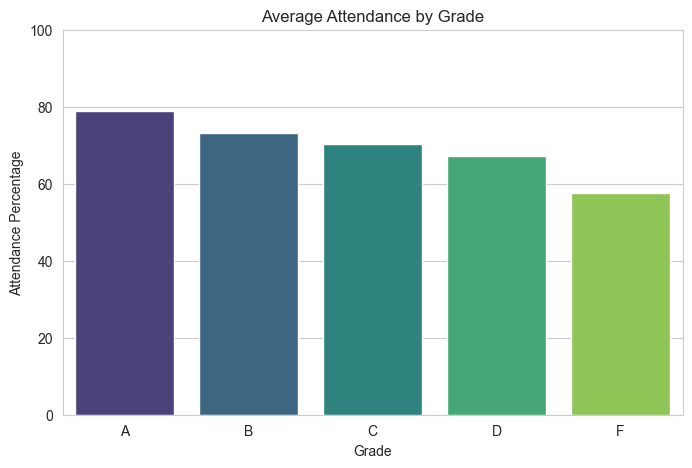

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

grade_attendance = df.groupby('grade')['attendance_percentage'].mean().reset_index()
plt.figure(figsize=(8,5))

sns.barplot(
    data=grade_attendance,
    x='grade',
    y='attendance_percentage',
    palette='viridis',
    hue = 'grade'
)

plt.title("Average Attendance by Grade")
plt.xlabel("Grade")
plt.ylabel("Attendance Percentage")

plt.ylim(0, 100)

plt.show()